# Recover Large-Run Data From W&B

This notebook pulls back what is definitely stored in Weights & Biases for the large `ctx512` runs.

It recovers:
- run summaries and logged history
- position-wise loss curves saved in W&B history
- backup artifact contents such as `run_summary.json`, `probes/*.json`, and `positionwise/*.json`

It also checks whether the AttnRes artifact contains saved depth-mixing rows (`depth_attention_rows`).

In [17]:
!pip install -q wandb pandas pyarrow matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import os
import wandb

os.environ["WANDB_API_KEY"] = "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"
os.environ.pop("WANDB_MODE", None)  # let repo choose auto
wandb.login(key=os.environ["WANDB_API_KEY"], relogin=True)
print("logged in")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/atin5551/.netrc


logged in


Set `WANDB_API_KEY` in the kernel before running the next cell.

Example:

```python
import os
os.environ["WANDB_API_KEY"] = "..."
```

In [19]:
import json
import os
from pathlib import Path

import pandas as pd
import wandb

def find_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/content/AttnResGPT-next-scale'),
        Path.home() / 'Documents' / 'GitHub' / 'AttnResGPT-next-scale',
    ]
    for candidate in candidates:
        if (candidate / 'src' / 'training' / 'train.py').exists() and (candidate / 'configs').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find AttnResGPT-next-scale from the current working directory.')

REPO_DIR = find_repo_root()
EXPORT_DIR = REPO_DIR / 'outputs' / 'wandb_recovery'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ENTITY = "atin5551-uc-davis"
PROJECT = "attnres-next-scale"

BASELINE_RUN = f"{ENTITY}/{PROJECT}/tinystories_large_baseline_ctx512_steps3000_seed42"
ATTNRES_RUN = f"{ENTITY}/{PROJECT}/tinystories_large_attnres_ctx512_steps3000_seed42"

BASELINE_ARTIFACT = f"{ENTITY}/{PROJECT}/large-ctx512-3000-baseline-outputs:latest"
ATTNRES_ARTIFACT = f"{ENTITY}/{PROJECT}/large-ctx512-3000-attnres-outputs:latest"
FULL_BACKUP_ARTIFACT = f"{ENTITY}/{PROJECT}/attnres-outputs-backup:latest"

assert os.environ.get("WANDB_API_KEY"), "Set WANDB_API_KEY before running this notebook."

wandb.login(key=os.environ["WANDB_API_KEY"], relogin=True)
api = wandb.Api()

baseline = api.run(BASELINE_RUN)
attnres = api.run(ATTNRES_RUN)

print("repo dir:", REPO_DIR)
print("baseline state:", baseline.state)
print("attnres state:", attnres.state)
print("export dir:", EXPORT_DIR)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/atin5551/.netrc


repo dir: /Users/atin5551/Documents/GitHub/AttnResGPT-next-scale
baseline state: finished
attnres state: finished
export dir: /Users/atin5551/Documents/GitHub/AttnResGPT-next-scale/outputs/wandb_recovery


In [20]:
def summarize_run(run):
    summary = dict(run.summary)
    interesting = sorted(
        key
        for key in summary.keys()
        if "positionwise" in key or "contribution" in key or "depth" in key
    )
    return {
        "run": run.path,
        "state": run.state,
        "summary_key_count": len(summary),
        "interesting_summary_keys": interesting,
    }

run_summary_df = pd.DataFrame([summarize_run(baseline), summarize_run(attnres)])
display(run_summary_df)

for run in [baseline, attnres]:
    print("\n", run.path)
    for key in sorted(k for k in run.summary.keys() if "positionwise" in k or "contribution" in k or "depth" in k)[:80]:
        print("  ", key)

,run,state,summary_key_count,interesting_summary_keys
0,"[atin5551-uc-davis, attnres-next-scale, tinyst...",finished,684,"[latest_positionwise_csv_path, latest_position..."
1,"[atin5551-uc-davis, attnres-next-scale, tinyst...",finished,692,"[depth_attention_entropy, early_contribution, ..."



 ['atin5551-uc-davis', 'attnres-next-scale', 'tinystories_large_baseline_ctx512_steps3000_seed42']
   latest_positionwise_csv_path
   latest_positionwise_json_path
   latest_positionwise_step
   positionwise_eval/elapsed_time_sec
   positionwise_eval/first_half_position_loss
   positionwise_eval/last_token_position_loss
   positionwise_eval/max_position_index
   positionwise_eval/max_position_loss
   positionwise_eval/mean_position_loss
   positionwise_eval/second_half_position_loss
   positionwise_eval/sequences_seen
   positionwise_eval/step
   positionwise_eval/tokens_seen
   positionwise_eval/tokens_seen_millions
   positionwise_loss/pos_0000
   positionwise_loss/pos_0001
   positionwise_loss/pos_0002
   positionwise_loss/pos_0003
   positionwise_loss/pos_0004
   positionwise_loss/pos_0005
   positionwise_loss/pos_0006
   positionwise_loss/pos_0007
   positionwise_loss/pos_0008
   positionwise_loss/pos_0009
   positionwise_loss/pos_0010
   positionwise_loss/pos_0011
   positionwis

In [ ]:
baseline_hist = pd.DataFrame(list(baseline.scan_history()))
attnres_hist = pd.DataFrame(list(attnres.scan_history()))

baseline_hist.to_csv(EXPORT_DIR / "baseline_large_ctx512_history.csv", index=False)
attnres_hist.to_csv(EXPORT_DIR / "attnres_large_ctx512_history.csv", index=False)

def interesting_history_columns(df):
    return sorted(
        col for col in df.columns
        if str(col).startswith("positionwise_eval/")
        or str(col).startswith("positionwise_loss/")
        or "contribution" in str(col)
        or "depth" in str(col)
    )

print("baseline interesting history columns:", len(interesting_history_columns(baseline_hist)))
print("attnres interesting history columns:", len(interesting_history_columns(attnres_hist)))
print("attnres sample interesting columns:")
for col in interesting_history_columns(attnres_hist)[:40]:
    print("  ", col)

baseline interesting history columns: 523
attnres interesting history columns: 531
attnres sample interesting columns:
   depth_attention_entropy
   early_contribution
   embedding_contribution
   late_contribution
   mean_depth_attention_entropy
   mean_early_contribution
   mean_embedding_contribution
   mean_late_contribution
   positionwise_eval/elapsed_time_sec
   positionwise_eval/first_half_position_loss
   positionwise_eval/last_token_position_loss
   positionwise_eval/max_position_index
   positionwise_eval/max_position_loss
   positionwise_eval/mean_position_loss
   positionwise_eval/second_half_position_loss
   positionwise_eval/sequences_seen
   positionwise_eval/step
   positionwise_eval/tokens_seen
   positionwise_eval/tokens_seen_millions
   positionwise_loss/pos_0000
   positionwise_loss/pos_0001
   positionwise_loss/pos_0002
   positionwise_loss/pos_0003
   positionwise_loss/pos_0004
   positionwise_loss/pos_0005
   positionwise_loss/pos_0006
   positionwise_loss/pos_0

In [22]:
def artifact_manifest_report(name):
    artifact = api.artifact(name)
    files = sorted(artifact.manifest.entries.keys())
    interesting = [
        path for path in files
        if "positionwise" in path
        or "probe" in path
        or "summary" in path
        or "metadata" in path
        or "checkpoint" in path
    ]
    return {
        "artifact": name,
        "type": artifact.type,
        "file_count": len(files),
        "interesting_files": interesting,
    }

artifact_report_df = pd.DataFrame([
    artifact_manifest_report(BASELINE_ARTIFACT),
    artifact_manifest_report(ATTNRES_ARTIFACT),
    artifact_manifest_report(FULL_BACKUP_ARTIFACT),
])
display(artifact_report_df[["artifact", "type", "file_count"]])

for row in artifact_report_df.to_dict(orient="records"):
    print("\n", row["artifact"])
    for path in row["interesting_files"][:120]:
        print("  ", path)

,artifact,type,file_count
0,atin5551-uc-davis/attnres-next-scale/large-ctx...,backup,70
1,atin5551-uc-davis/attnres-next-scale/large-ctx...,backup,79
2,atin5551-uc-davis/attnres-next-scale/attnres-o...,backup,1



 atin5551-uc-davis/attnres-next-scale/large-ctx512-3000-baseline-outputs:latest
   positionwise/step_0001000.csv
   positionwise/step_0001000.json
   positionwise/step_0002000.csv
   positionwise/step_0002000.json
   positionwise/step_0003000.csv
   positionwise/step_0003000.json
   probes/step_0000001.json
   probes/step_0000100.json
   probes/step_0000200.json
   probes/step_0000300.json
   probes/step_0000400.json
   probes/step_0000500.json
   probes/step_0000600.json
   probes/step_0000700.json
   probes/step_0000800.json
   probes/step_0000900.json
   probes/step_0001000.json
   probes/step_0001100.json
   probes/step_0001200.json
   probes/step_0001300.json
   probes/step_0001400.json
   probes/step_0001500.json
   probes/step_0001600.json
   probes/step_0001700.json
   probes/step_0001800.json
   probes/step_0001900.json
   probes/step_0002000.json
   probes/step_0002100.json
   probes/step_0002200.json
   probes/step_0002300.json
   probes/step_0002400.json
   probes/step_000

In [23]:
ARTIFACT_FILE_DIR = EXPORT_DIR / "artifact_files"
ARTIFACT_FILE_DIR.mkdir(parents=True, exist_ok=True)

def download_json_from_artifact(artifact_name, relative_path, local_name):
    artifact = api.artifact(artifact_name)
    local_path = Path(artifact.get_path(relative_path).download(root=str(ARTIFACT_FILE_DIR / local_name)))
    return json.loads(local_path.read_text())

baseline_run_summary = download_json_from_artifact(BASELINE_ARTIFACT, "run_summary.json", "baseline_run_summary")
baseline_pos_3000 = download_json_from_artifact(BASELINE_ARTIFACT, "positionwise/step_0003000.json", "baseline_pos_3000")

attnres_run_summary = download_json_from_artifact(ATTNRES_ARTIFACT, "run_summary.json", "attnres_run_summary")
attnres_probe_3000 = download_json_from_artifact(ATTNRES_ARTIFACT, "probes/step_0003000.json", "attnres_probe_3000")
attnres_pos_3000 = download_json_from_artifact(ATTNRES_ARTIFACT, "positionwise/step_0003000.json", "attnres_pos_3000")

print("AttnRes run_summary has depth_attention_rows:", "depth_attention_rows" in attnres_run_summary)
print("AttnRes run_summary depth row count:", len(attnres_run_summary.get("depth_attention_rows", [])))
print("AttnRes probe@3000 depth row count:", len(attnres_probe_3000.get("depth_attention_rows", [])))
print("AttnRes probe@3000 first row width:", len(attnres_probe_3000.get("depth_attention_rows", [])[0]) if attnres_probe_3000.get("depth_attention_rows") else 0)
print("AttnRes positionwise@3000 length:", len(attnres_pos_3000.get("position_losses", [])))
print("AttnRes positionwise mean loss:", attnres_pos_3000.get("mean_position_loss"))

wandb: WARNING Artifact.get_path(name) is deprecated, use Artifact.get_entry(name) instead.


AttnRes run_summary has depth_attention_rows: True
AttnRes run_summary depth row count: 25
AttnRes probe@3000 depth row count: 25
AttnRes probe@3000 first row width: 1
AttnRes positionwise@3000 length: 512
AttnRes positionwise mean loss: 1.948872685432434


The saved AttnRes depth rows are **mean depth weights**, not the full raw per-token alpha tensor.

They are still very useful for analysis because they preserve the per-mixing-site source weighting structure.

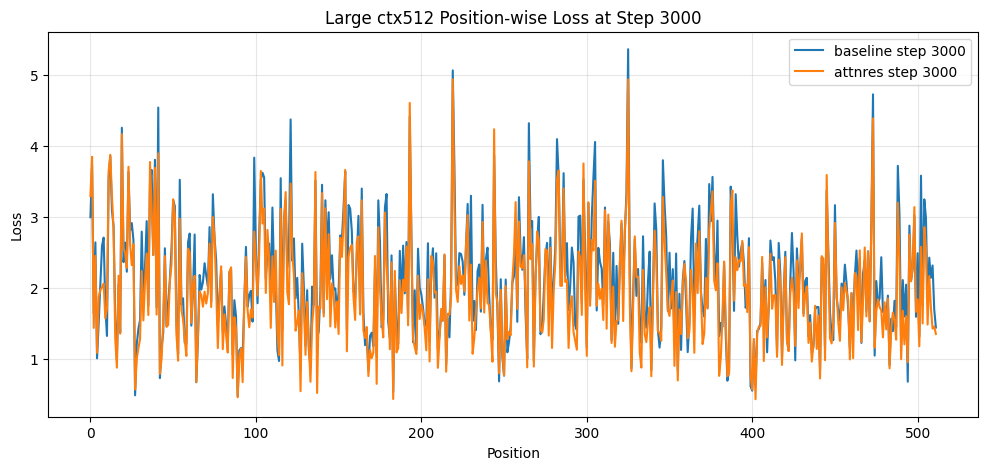

In [24]:
import matplotlib.pyplot as plt

baseline_y = baseline_pos_3000["position_losses"]
attnres_y = attnres_pos_3000["position_losses"]
x = list(range(len(attnres_y)))

plt.figure(figsize=(12, 5))
plt.plot(x, baseline_y, label="baseline step 3000")
plt.plot(x, attnres_y, label="attnres step 3000")
plt.xlabel("Position")
plt.ylabel("Loss")
plt.title("Large ctx512 Position-wise Loss at Step 3000")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

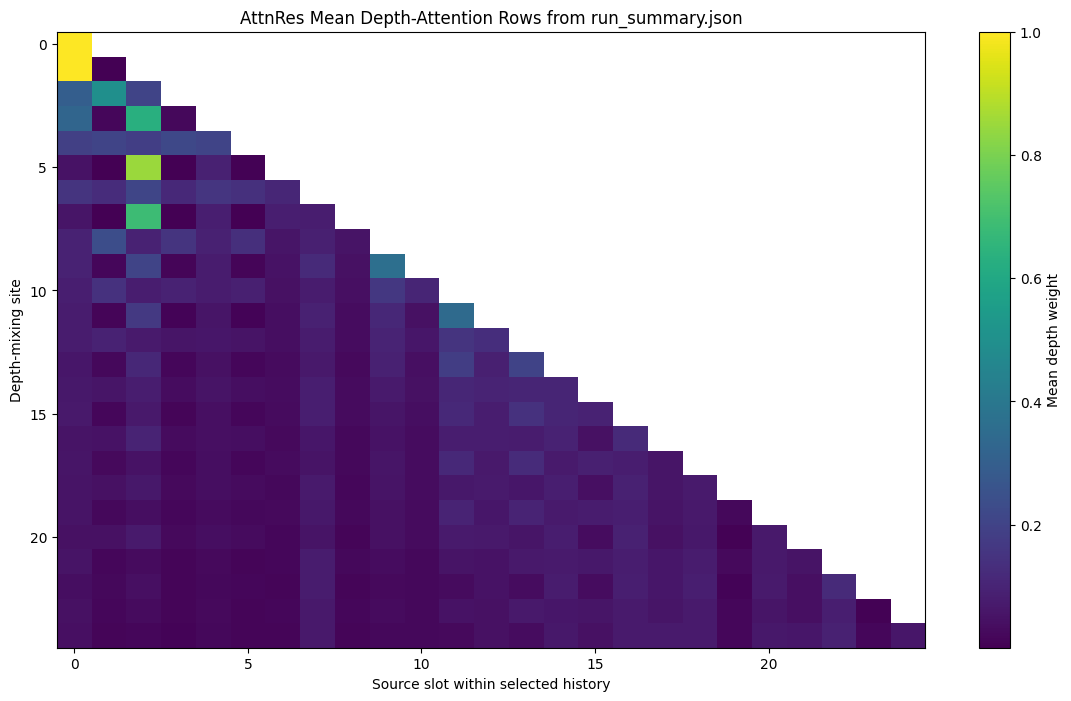

,mixing_site,source_indices
0,0,[0]
1,1,"[0, 1]"
2,2,"[0, 1, 2]"
3,3,"[0, 1, 2, 3]"
4,4,"[0, 1, 2, 3, 4]"
5,5,"[0, 1, 2, 3, 4, 5]"
6,6,"[0, 1, 2, 3, 4, 5, 6]"
7,7,"[0, 1, 2, 3, 4, 5, 6, 7]"
8,8,"[0, 1, 2, 3, 4, 5, 6, 7, 8]"
9,9,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


In [25]:
import math
import numpy as np

rows = attnres_run_summary.get("depth_attention_rows", [])
source_indices = attnres_run_summary.get("depth_source_indices", [])

max_width = max(len(row) for row in rows)
padded = np.full((len(rows), max_width), np.nan, dtype=float)
for i, row in enumerate(rows):
    padded[i, : len(row)] = row

plt.figure(figsize=(14, 8))
im = plt.imshow(padded, aspect="auto", interpolation="nearest")
plt.colorbar(im, label="Mean depth weight")
plt.xlabel("Source slot within selected history")
plt.ylabel("Depth-mixing site")
plt.title("AttnRes Mean Depth-Attention Rows from run_summary.json")
plt.show()

source_index_preview = pd.DataFrame({
    "mixing_site": list(range(len(source_indices))),
    "source_indices": [str(indices) for indices in source_indices],
})
display(source_index_preview.head(10))